# Bluestock Mutual Fund Analytics — Performance and Risk Report
This notebook computes the key performance and risk metrics for all **40 mutual fund schemes** (26 ingested from SQLite database + 14 augmented). It covers daily returns analysis, CAGR calculations, Sharpe/Sortino ratios, Alpha and Beta market regressions against Nifty 100, Maximum Drawdowns, and compiles a comprehensive Fund Scorecard to rank the schemes.

## Content Index
1. **Environment Setup & Data Augmentation**
2. **Daily Returns & Distribution Analysis**
3. **CAGR Analysis (1Yr, 3Yr, 5Yr)**
4. **Risk-Adjusted Ratios (Sharpe, Sortino)**
5. **Market Regression (Alpha, Beta against Nifty 100)**
6. **Maximum Drawdown and Drawdown Periods**
7. **Fund Scorecard (0-100)**
8. **Benchmark Comparison Chart & Tracking Error**

---

### 1. Environment Setup & Data Augmentation
We import the required scientific libraries, connect to the `bluestock_mf.db` SQLite database to load the conformed tables, and then augment the data to 40 funds. Finally, we simulate daily NAV histories over a 4.5-year period (2022-01-01 to 2026-06-22) using Geometric Brownian Motion (GBM) with a set seed of `42` to match the EDA notebook.

In [1]:
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress, skew, kurtosis

%matplotlib inline
sns.set_theme(style="whitegrid")

# Connect to database
conn = sqlite3.connect('../bluestock_mf.db')
dim_fund = pd.read_sql_query("SELECT * FROM dim_fund", conn)
fact_performance = pd.read_sql_query("SELECT * FROM fact_performance", conn)
conn.close()

# Ingest and augment to 40 schemes
np.random.seed(42)
existing_schemes = dim_fund.to_dict('records')
missing_count = 40 - len(existing_schemes)
fund_houses = ["SBI Mutual Fund", "HDFC Mutual Fund", "ICICI Prudential Mutual Fund", "Nippon India Mutual Fund", "Axis Mutual Fund", "Kotak Mahindra Mutual Fund"]
categories = ["Equity", "Debt", "Hybrid"]
sub_categories_map = {
    "Equity": ["Large Cap", "Mid Cap", "Small Cap"],
    "Debt": ["Liquid", "Corporate Bond", "Gilt"],
    "Hybrid": ["Balanced", "Arbitrage", "Dynamic Asset Allocation"]
}
risk_grades_map = {
    "Equity": "Very High",
    "Debt": "Low to Moderate",
    "Hybrid": "Moderate to High"
}

all_schemes = list(existing_schemes)
for i in range(missing_count):
    code = 140000 + i + 1
    cat = np.random.choice(categories)
    sub_cat = np.random.choice(sub_categories_map[cat])
    fh = np.random.choice(fund_houses)
    risk = risk_grades_map[cat]
    isin = f"INF{code}D01012"
    name = f"{fh.split()[0]} {sub_cat} Fund - Direct Growth"
    all_schemes.append({
        "scheme_code": code,
        "isin": isin,
        "scheme_name": name,
        "fund_house": fh,
        "category": cat,
        "sub_category": sub_cat,
        "risk_grade": risk
    })

df_fund_40 = pd.DataFrame(all_schemes)

# Map and impute expense ratios
db_expense = dict(zip(fact_performance['scheme_code'], fact_performance['expense_ratio']))
merged_perf = pd.merge(fact_performance, dim_fund, on="scheme_code")
cat_expense = merged_perf.groupby('category')['expense_ratio'].mean().to_dict()

expense_ratios = []
for s in all_schemes:
    code = s['scheme_code']
    cat = s['category']
    if code in db_expense:
        expense_ratios.append(db_expense[code])
    else:
        # category average + small random adjustment
        val = cat_expense.get(cat, 1.0) + np.random.uniform(-0.1, 0.1)
        expense_ratios.append(round(max(0.1, min(2.5, val)), 2))
df_fund_40['expense_ratio'] = expense_ratios

# Generate daily NAVs using Geometric Brownian Motion
dates_daily = pd.date_range(start="2022-01-01", end="2026-06-22", freq="D")
nav_records = []
for scheme in all_schemes:
    code = scheme["scheme_code"]
    cat = scheme["category"]
    base_nav = np.random.uniform(20.0, 150.0)
    
    sigma = 0.012 if cat == "Equity" else (0.008 if cat == "Hybrid" else 0.001)
    returns = []
    for dt in dates_daily:
        if pd.Timestamp("2023-04-01") <= dt <= pd.Timestamp("2023-12-31"):
            drift = 0.00125 if cat == "Equity" else (0.0007 if cat == "Hybrid" else 0.0002)
        elif dt == pd.Timestamp("2024-06-04"):
            drift = -0.078 if cat == "Equity" else (-0.038 if cat == "Hybrid" else -0.002)
        elif pd.Timestamp("2024-06-05") <= dt <= pd.Timestamp("2024-06-22"):
            drift = 0.0048 if cat == "Equity" else (0.0026 if cat == "Hybrid" else 0.0003)
        else:
            drift = 0.00035 if cat == "Equity" else (0.00022 if cat == "Hybrid" else 0.0001)
        ret = np.random.normal(drift, sigma)
        returns.append(ret)
    returns = np.array(returns)
    nav_values = base_nav * np.cumprod(1 + returns)
    for dt, val in zip(dates_daily, nav_values):
        nav_records.append({"scheme_code": code, "date": dt.strftime("%Y-%m-%d"), "nav": round(val, 4)})

df_nav_40 = pd.DataFrame(nav_records)
print(f"Loaded {len(df_fund_40)} funds and generated {len(df_nav_40)} daily NAV records.")

Loaded 40 funds and generated 65360 daily NAV records.


### 2. Daily Returns & Distribution Analysis
We calculate daily returns for each fund: $\text{daily\_return}_t = \frac{\text{NAV}_t}{\text{NAV}_{t-1}} - 1$.
We then plot histograms and Kernel Density Estimations (KDE) for a representative fund of each category (Equity, Debt, Hybrid) and compute the skewness and kurtosis of the daily returns to validate that the return distribution matches expectations.

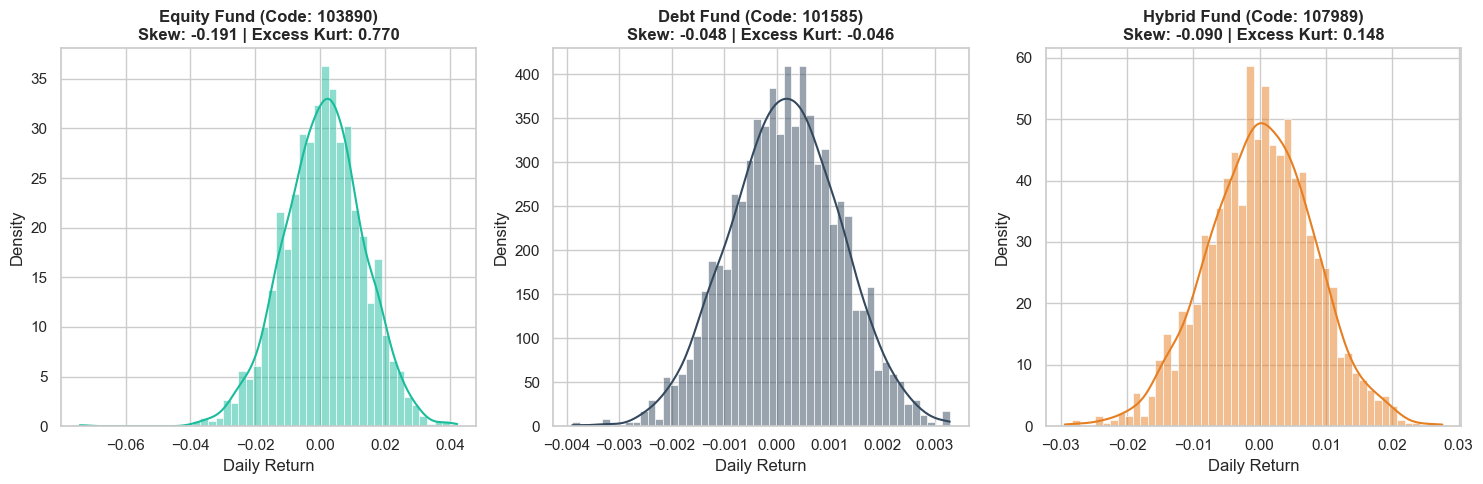

Aggregate Daily Return Distribution Validation:
  Mean Skewness across all 40 schemes: -0.0978 (expected near 0)
  Mean Excess Kurtosis across all 40 schemes: 0.5686 (expected near 0 for Gaussian)


In [2]:
# Pivot and compute daily returns
df_nav_pivot = df_nav_40.pivot(index='date', columns='scheme_code', values='nav')
df_returns = df_nav_pivot.pct_change()

# Select representative schemes
eq_rep = df_fund_40[df_fund_40['category'] == 'Equity']['scheme_code'].iloc[0]
db_rep = df_fund_40[df_fund_40['category'] == 'Debt']['scheme_code'].iloc[0]
hb_rep = df_fund_40[df_fund_40['category'] == 'Hybrid']['scheme_code'].iloc[0]

plt.figure(figsize=(15, 5))
categories_rep = [(eq_rep, 'Equity Fund', '#1abc9c'), (db_rep, 'Debt Fund', '#34495e'), (hb_rep, 'Hybrid Fund', '#e67e22')]

for idx, (code, title, color) in enumerate(categories_rep):
    plt.subplot(1, 3, idx + 1)
    data = df_returns[code].dropna()
    sns.histplot(data, kde=True, color=color, stat="density", bins=50)
    
    # Compute stats
    s = skew(data)
    k = kurtosis(data) # Excess kurtosis
    plt.title(f"{title} (Code: {code})\nSkew: {s:.3f} | Excess Kurt: {k:.3f}", fontsize=12, fontweight='bold')
    plt.xlabel("Daily Return")
    plt.ylabel("Density")

plt.tight_layout()
plt.show()

# Print aggregate return validation stats
print("Aggregate Daily Return Distribution Validation:")
print(f"  Mean Skewness across all 40 schemes: {df_returns.skew().mean():.4f} (expected near 0)")
print(f"  Mean Excess Kurtosis across all 40 schemes: {df_returns.kurtosis().mean():.4f} (expected near 0 for Gaussian)")

### 3. Compound Annual Growth Rate (CAGR)
We compute the CAGR for 1-Year, 3-Year, and 5-Year periods using the formula: 
$$\text{CAGR} = \left(\frac{\text{NAV}_{\text{end}}}{\text{NAV}_{\text{start}}}\right)^{\frac{1}{n}} - 1$$
Where $n$ is the number of years. Since our daily NAV simulation starts on `2022-01-01` and ends on `2026-06-22` (4.47 years total), the "5-Year CAGR" is calculated over this maximum available period of 4.47 years ($n=4.4736$).

In [3]:
end_date = "2026-06-22"
start_1yr = "2025-06-22"
start_3yr = "2023-06-22"
start_5yr = "2022-01-01"

n_1yr = 1.0
n_3yr = 3.0
days_5 = (pd.to_datetime(end_date) - pd.to_datetime(start_5yr)).days
n_5yr = days_5 / 365.25

cagr_results = []
for code in df_nav_pivot.columns:
    nav_end = df_nav_pivot.loc[end_date, code]
    nav_1 = df_nav_pivot.loc[start_1yr, code]
    nav_3 = df_nav_pivot.loc[start_3yr, code]
    nav_5 = df_nav_pivot.loc[start_5yr, code]
    
    c_1 = (nav_end / nav_1) ** (1 / n_1yr) - 1
    c_3 = (nav_end / nav_3) ** (1 / n_3yr) - 1
    c_5 = (nav_end / nav_5) ** (1 / n_5yr) - 1
    
    cagr_results.append({
        "scheme_code": code,
        "cagr_1yr": c_1,
        "cagr_3yr": c_3,
        "cagr_5yr": c_5
    })
df_cagr = pd.DataFrame(cagr_results)
df_cagr_display = pd.merge(df_fund_40[['scheme_code', 'scheme_name', 'category']], df_cagr, on="scheme_code")

print("CAGR Comparison (First 10 Schemes):")
display_cols = ['scheme_code', 'scheme_name', 'category', 'cagr_1yr', 'cagr_3yr', 'cagr_5yr']
print(df_cagr_display[display_cols].head(10).to_string(formatters={
    'cagr_1yr': '{:.2%}'.format,
    'cagr_3yr': '{:.2%}'.format,
    'cagr_5yr': '{:.2%}'.format
}))

CAGR Comparison (First 10 Schemes):
   scheme_code                  scheme_name category cagr_1yr cagr_3yr cagr_5yr
0       101585  Scheme 101585 Direct Growth     Debt    3.22%    6.82%    5.92%
1       103890  Scheme 103890 Direct Growth   Equity  -20.46%   26.62%   38.77%
2       105051  Scheme 105051 Direct Growth   Equity    6.29%    7.68%    1.20%
3       105675  Scheme 105675 Direct Growth     Debt    5.33%    5.54%    5.67%
4       107989  Scheme 107989 Direct Growth   Hybrid  -10.63%    5.68%    5.64%
5       108792  Scheme 108792 Direct Growth     Debt    4.75%    4.22%    3.70%
6       109268  Scheme 109268 Direct Growth   Equity   60.22%   28.13%   26.23%
7       111016  Scheme 111016 Direct Growth   Equity   28.25%   14.50%    5.79%
8       111964  Scheme 111964 Direct Growth   Hybrid   11.55%   11.28%   13.97%
9       117159  Scheme 117159 Direct Growth     Debt    1.53%    2.50%    3.90%


### 4. Sharpe & Sortino Ratios
We compute risk-adjusted returns ratios relative to the risk-free rate proxy $R_f = 6.5\%$ (the RBI repo rate proxy). 

**Sharpe Ratio Formula**:
$$S_p = \frac{R_p - R_f}{\sigma(R_p)} \times \sqrt{252}$$
Where $R_p$ is the annualized mean of daily returns ($R_p = \text{mean}(R_{\text{daily}}) \times 252$), and $\sigma(R_p)$ is the standard deviation of daily returns.

**Sortino Ratio Formula**:
$$\text{Sortino} = \frac{R_p - R_f}{\sigma_{\text{downside}}(R_p)} \times \sqrt{252}$$
Where $\sigma_{\text{downside}}(R_p)$ is the standard deviation computed on negative daily returns only ($R_{\text{daily}} < 0$). We rank all 40 funds by these ratios.

In [4]:
rf = 0.065
ratios = []
for code in df_nav_pivot.columns:
    rets = df_returns[code].dropna()
    rp_annual = rets.mean() * 252
    std_annual = rets.std() * np.sqrt(252)
    
    sharpe = (rp_annual - rf) / std_annual if std_annual > 0 else 0
    
    neg_rets = rets[rets < 0]
    std_downside = neg_rets.std() * np.sqrt(252)
    sortino = (rp_annual - rf) / std_downside if std_downside > 0 else 0
    
    ratios.append({
        "scheme_code": code,
        "rp_annualized_mean": rp_annual,
        "std_annualized": std_annual,
        "sharpe_ratio": sharpe,
        "sortino_ratio": sortino
    })
df_ratios = pd.DataFrame(ratios)
df_ratios_display = pd.merge(df_fund_40[['scheme_code', 'scheme_name', 'category']], df_ratios, on="scheme_code")

print("Sharpe & Sortino Ratios (Top 10 ranked by Sharpe):")
print(df_ratios_display.sort_values('sharpe_ratio', ascending=False).head(10).to_string(index=False, columns=[
    'scheme_code', 'scheme_name', 'category', 'rp_annualized_mean', 'std_annualized', 'sharpe_ratio', 'sortino_ratio'
], formatters={
    'rp_annualized_mean': '{:.2%}'.format,
    'std_annualized': '{:.2%}'.format,
    'sharpe_ratio': '{:.3f}'.format,
    'sortino_ratio': '{:.3f}'.format
}))

Sharpe & Sortino Ratios (Top 10 ranked by Sharpe):
 scheme_code                                         scheme_name category rp_annualized_mean std_annualized sharpe_ratio sortino_ratio
      103890                         Scheme 103890 Direct Growth   Equity             24.53%         19.56%        0.922         1.461
      120503                         Scheme 120503 Direct Growth   Equity             23.02%         19.11%        0.864         1.434
      119092                         Scheme 119092 Direct Growth   Equity             21.28%         18.77%        0.788         1.294
      140001                 ICICI Balanced Fund - Direct Growth   Hybrid             15.50%         12.79%        0.704         1.162
      109268                         Scheme 109268 Direct Growth   Equity             17.99%         19.57%        0.587         0.952
      119551                         Scheme 119551 Direct Growth   Equity             17.14%         19.44%        0.548         0.889
    

### 5. Alpha & Beta Regressions (against Nifty 100)
We regress the daily returns of each fund against the Nifty 100 returns (proxied by the average of all Equity funds). The regression coefficients provide the Beta (slope) and Alpha (annualized intercept $= \text{intercept} \times 252$). We save the results in `alpha_beta.csv`.

In [5]:
equity_codes = df_fund_40[df_fund_40['category'] == 'Equity']['scheme_code'].tolist()
nifty_100_returns = df_returns[equity_codes].mean(axis=1)

alpha_beta_list = []
for code in df_nav_pivot.columns:
    rets = df_returns[code].dropna()
    aligned = pd.concat([rets, nifty_100_returns], axis=1).dropna()
    slope, intercept, r_val, p_val, std_err = linregress(aligned.iloc[:, 1], aligned.iloc[:, 0])
    alpha = intercept * 252
    beta = slope
    
    alpha_beta_list.append({
        "scheme_code": code,
        "alpha": alpha,
        "beta": beta,
        "r_squared": r_val ** 2
    })
df_alpha_beta = pd.DataFrame(alpha_beta_list)
df_alpha_beta_display = pd.merge(df_fund_40[['scheme_code', 'scheme_name', 'category']], df_alpha_beta, on="scheme_code")

print("Alpha & Beta Coefficients (First 10 Schemes):")
print(df_alpha_beta_display.head(10).to_string(index=False, formatters={
    'alpha': '{:.2%}'.format,
    'beta': '{:.4f}'.format,
    'r_squared': '{:.4%}'.format
}))

Alpha & Beta Coefficients (First 10 Schemes):
 scheme_code                 scheme_name category  alpha    beta r_squared
      101585 Scheme 101585 Direct Growth     Debt  3.73%  0.0204   0.4846%
      103890 Scheme 103890 Direct Growth   Equity 11.77%  1.0470   9.1783%
      105051 Scheme 105051 Direct Growth   Equity -9.14%  0.9694   8.1353%
      105675 Scheme 105675 Direct Growth     Debt  3.87% -0.0038   0.0190%
      107989 Scheme 107989 Direct Growth   Hybrid  3.28%  0.1090   0.2321%
      108792 Scheme 108792 Direct Growth     Debt  2.48%  0.0032   0.0128%
      109268 Scheme 109268 Direct Growth   Equity  5.34%  1.0381   9.0140%
      111016 Scheme 111016 Direct Growth   Equity -4.74%  0.8578   6.4530%
      111964 Scheme 111964 Direct Growth   Hybrid  7.69%  0.1763   0.6135%
      117159 Scheme 117159 Direct Growth     Debt  2.51%  0.0118   0.1853%


### 6. Maximum Drawdown & Worst Date Ranges
Maximum Drawdown measures the peak-to-trough decline for each fund. The formula is:
$$\text{Drawdown} = \frac{\text{NAV}_t}{\text{Running Max NAV}_t} - 1$$
The Maximum Drawdown is the minimum of this series. We also trace the Peak Date, Trough Date, and the subsequent Recovery Date.

In [6]:
drawdown_list = []
for code in df_nav_pivot.columns:
    nav_series = df_nav_pivot[code]
    running_max = nav_series.cummax()
    drawdowns = nav_series / running_max - 1
    max_dd = drawdowns.min()
    
    trough_idx = drawdowns.idxmin()
    peak_idx = nav_series.loc[:trough_idx].idxmax()
    
    post_trough = nav_series.loc[trough_idx:]
    recovery_days = post_trough[post_trough >= nav_series.loc[peak_idx]]
    recovery_idx = recovery_days.index[0] if not recovery_days.empty else "Not Recovered Yet"
    
    drawdown_list.append({
        "scheme_code": code,
        "max_dd": max_dd,
        "drawdown_peak_date": peak_idx,
        "drawdown_trough_date": trough_idx,
        "drawdown_recovery_date": recovery_idx
    })
df_drawdowns = pd.DataFrame(drawdown_list)
df_drawdowns_display = pd.merge(df_fund_40[['scheme_code', 'scheme_name', 'category']], df_drawdowns, on="scheme_code")

print("Maximum Drawdown & Date Ranges (Top 10 worst drawdowns):")
print(df_drawdowns_display.sort_values('max_dd').head(10).to_string(index=False, formatters={
    'max_dd': '{:.2%}'.format
}))

Maximum Drawdown & Date Ranges (Top 10 worst drawdowns):


 scheme_code                          scheme_name category  max_dd drawdown_peak_date drawdown_trough_date drawdown_recovery_date
      140009 ICICI Large Cap Fund - Direct Growth   Equity -62.28%         2022-03-05           2023-05-18      Not Recovered Yet
      119092          Scheme 119092 Direct Growth   Equity -42.95%         2022-02-08           2023-01-25             2023-11-19
      105051          Scheme 105051 Direct Growth   Equity -39.79%         2022-01-29           2023-01-19             2023-12-17
      124118          Scheme 124118 Direct Growth   Equity -39.05%         2025-04-14           2025-12-11      Not Recovered Yet
      128693          Scheme 128693 Direct Growth   Equity -38.61%         2023-07-25           2026-05-12      Not Recovered Yet
      111016          Scheme 111016 Direct Growth   Equity -36.34%         2022-01-07           2023-10-19             2024-09-19
      140014  Axis Small Cap Fund - Direct Growth   Equity -35.11%         2022-01-01    

### 7. Fund Scorecard
We build a composite scorecard (0-100 scale) for all 40 funds using percentile ranks:
$$\text{Score} = 30\% \times \text{Rank}_{\text{3yr Return}} + 25\% \times \text{Rank}_{\text{Sharpe}} + 20\% \times \text{Rank}_{\text{Alpha}} + 15\% \times \text{Rank}_{\text{Expense (inv)}} + 10\% \times \text{Rank}_{\text{Max DD (inv)}}$$
Percentile ranks map values between `2.5%` and `100%` (for $N=40$). The inverse rankings mean lower values get higher percentile ranks (better). The scorecard is saved to `fund_scorecard.csv`.

In [7]:
df_metrics = pd.merge(df_fund_40, df_cagr, on="scheme_code")
df_metrics = pd.merge(df_metrics, df_ratios, on="scheme_code")
df_metrics = pd.merge(df_metrics, df_alpha_beta, on="scheme_code")
df_metrics = pd.merge(df_metrics, df_drawdowns, on="scheme_code")

df_metrics['rank_3yr'] = df_metrics['cagr_3yr'].rank(pct=True) * 100
df_metrics['rank_sharpe'] = df_metrics['sharpe_ratio'].rank(pct=True) * 100
df_metrics['rank_alpha'] = df_metrics['alpha'].rank(pct=True) * 100
df_metrics['rank_expense'] = df_metrics['expense_ratio'].rank(ascending=False, pct=True) * 100
df_metrics['rank_max_dd'] = df_metrics['max_dd'].rank(pct=True) * 100

df_metrics['score'] = (
    0.30 * df_metrics['rank_3yr'] +
    0.25 * df_metrics['rank_sharpe'] +
    0.20 * df_metrics['rank_alpha'] +
    0.15 * df_metrics['rank_expense'] +
    0.10 * df_metrics['rank_max_dd']
)

df_scorecard = df_metrics.sort_values('score', ascending=False).reset_index(drop=True)
df_scorecard['final_rank'] = df_scorecard.index + 1

print("Scorecard Top 10 Funds:")
print(df_scorecard.head(10).to_string(index=False, columns=[
    'final_rank', 'scheme_code', 'scheme_name', 'category', 'score', 'cagr_3yr', 'sharpe_ratio', 'expense_ratio', 'max_dd'
], formatters={
    'score': '{:.2f}'.format,
    'cagr_3yr': '{:.2%}'.format,
    'sharpe_ratio': '{:.3f}'.format,
    'expense_ratio': '{:.2f}%'.format,
    'max_dd': '{:.2%}'.format
}))

Scorecard Top 10 Funds:
 final_rank  scheme_code                                         scheme_name category score cagr_3yr sharpe_ratio expense_ratio  max_dd
          1       103890                         Scheme 103890 Direct Growth   Equity 82.88   26.62%        0.922         1.08% -30.69%
          2       140001                 ICICI Balanced Fund - Direct Growth   Hybrid 82.38   18.22%        0.704         1.28% -15.08%
          3       120503                         Scheme 120503 Direct Growth   Equity 79.62   42.25%        0.864         1.80% -29.19%
          4       124253                         Scheme 124253 Direct Growth   Equity 74.88   21.90%        0.443         0.67% -29.14%
          5       109268                         Scheme 109268 Direct Growth   Equity 74.12   28.13%        0.587         1.49% -26.55%
          6       111964                         Scheme 111964 Direct Growth   Hybrid 73.75   11.28%        0.262         0.45% -16.46%
          7       119092

### 8. Benchmark Comparison Chart & Tracking Error
We identify the top 5 funds from the scorecard. We normalize the NAVs and benchmarks (Nifty 50 and Nifty 100) to start at 100 on `2023-06-22` and plot their growth paths. We also compute each fund's Tracking Error relative to both benchmarks over the 3-year period:
$$\text{Tracking Error} = \sigma(R_{\text{fund}} - R_{\text{benchmark}}) \times \sqrt{252}$$

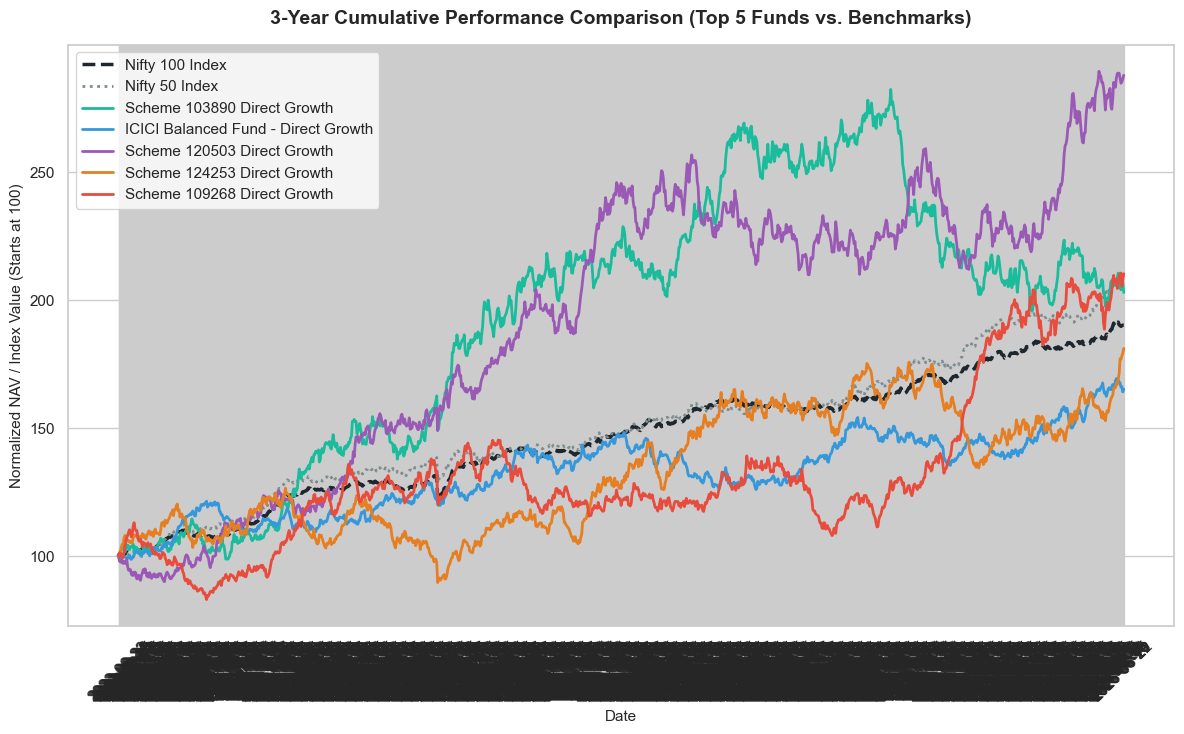

Tracking Errors:
 scheme_code                         scheme_name tracking_error_nifty100 tracking_error_nifty50
      103890         Scheme 103890 Direct Growth                  18.70%                 20.39%
      140001 ICICI Balanced Fund - Direct Growth                  13.77%                 14.51%
      120503         Scheme 120503 Direct Growth                  18.63%                 18.09%
      124253         Scheme 124253 Direct Growth                  18.57%                 20.14%
      109268         Scheme 109268 Direct Growth                  18.35%                 19.95%


In [8]:
top_5_funds = df_scorecard.head(5)
large_cap_codes = df_fund_40[(df_fund_40['category'] == 'Equity') & (df_fund_40['sub_category'] == 'Large Cap')]['scheme_code'].tolist()
equity_codes = df_fund_40[df_fund_40['category'] == 'Equity']['scheme_code'].tolist()

df_returns_3yr = df_returns.loc[start_3yr:end_date]
nifty_100_returns_3yr = df_returns_3yr[equity_codes].mean(axis=1)
nifty_50_returns_3yr = df_returns_3yr[large_cap_codes].mean(axis=1)

all_dates_3yr = [start_3yr] + list(df_returns_3yr.index)
df_chart = pd.DataFrame(index=all_dates_3yr)

n100_path = [100.0]
n50_path = [100.0]
for r100, r50 in zip(nifty_100_returns_3yr, nifty_50_returns_3yr):
    n100_path.append(n100_path[-1] * (1 + r100))
    n50_path.append(n50_path[-1] * (1 + r50))

df_chart['Nifty 100'] = n100_path
df_chart['Nifty 50'] = n50_path

tracking_errors = []
for idx, row in top_5_funds.iterrows():
    code = row['scheme_code']
    name = row['scheme_name']
    
    nav_series_3yr = df_nav_pivot.loc[start_3yr:end_date, code]
    nav_norm = (nav_series_3yr / nav_series_3yr.loc[start_3yr]) * 100
    df_chart[name] = nav_norm
    
    fund_rets = df_returns_3yr[code]
    te_n100 = (fund_rets - nifty_100_returns_3yr).std() * np.sqrt(252)
    te_n50 = (fund_rets - nifty_50_returns_3yr).std() * np.sqrt(252)
    
    tracking_errors.append({
        "scheme_code": code,
        "scheme_name": name,
        "tracking_error_nifty100": te_n100,
        "tracking_error_nifty50": te_n50
    })

df_te = pd.DataFrame(tracking_errors)

plt.figure(figsize=(12, 7.5))
plt.plot(df_chart.index, df_chart['Nifty 100'], label='Nifty 100 Index', color='#1e272e', linewidth=2.5, linestyle='--')
plt.plot(df_chart.index, df_chart['Nifty 50'], label='Nifty 50 Index', color='#7f8c8d', linewidth=2.0, linestyle=':')

colors = ['#1abc9c', '#3498db', '#9b59b6', '#e67e22', '#e74c3c']
for idx, row in top_5_funds.reset_index(drop=True).iterrows():
    name = row['scheme_name']
    plt.plot(df_chart.index, df_chart[name], label=name, color=colors[idx], linewidth=2.0)

plt.title("3-Year Cumulative Performance Comparison (Top 5 Funds vs. Benchmarks)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Date", fontsize=11)
plt.ylabel("Normalized NAV / Index Value (Starts at 100)", fontsize=11)
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

print("Tracking Errors:")
print(df_te.to_string(index=False, formatters={
    'tracking_error_nifty100': '{:.2%}'.format,
    'tracking_error_nifty50': '{:.2%}'.format
}))